<a href="https://colab.research.google.com/github/KrishnaChaitanya-aiml/iot-sensor-anomaly-detection/blob/main/iot_sensor_anomaly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smart IoT Sensor Anomaly Detection System

## Problem Statement
IoT systems generate continuous sensor data which may contain abnormal readings due to faults or unusual conditions. Detecting these anomalies is critical for maintaining system reliability.

## Objective
To identify anomalies in sensor data using statistical techniques and visualize them effectively.

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Generation

Simulating IoT sensor temperature data with normal behavior and injected anomalies.

In [3]:
# Generate synthetic IoT sensor data
np.random.seed(42)

# Normal temperature data
normal_data = np.random.normal(loc=25, scale=2, size=120)

# Inject anomalies
normal_data[20] = 40
normal_data[60] = 5
normal_data[100] = 45

# Create DataFrame
df = pd.DataFrame({
    'Time': range(len(normal_data)),
    'Temperature': normal_data
})

df.head()

,Time,Temperature
0,0,25.993428
1,1,24.723471
2,2,26.295377
3,3,28.046060
4,4,24.531693


## Data Visualization

Visualizing sensor readings over time.

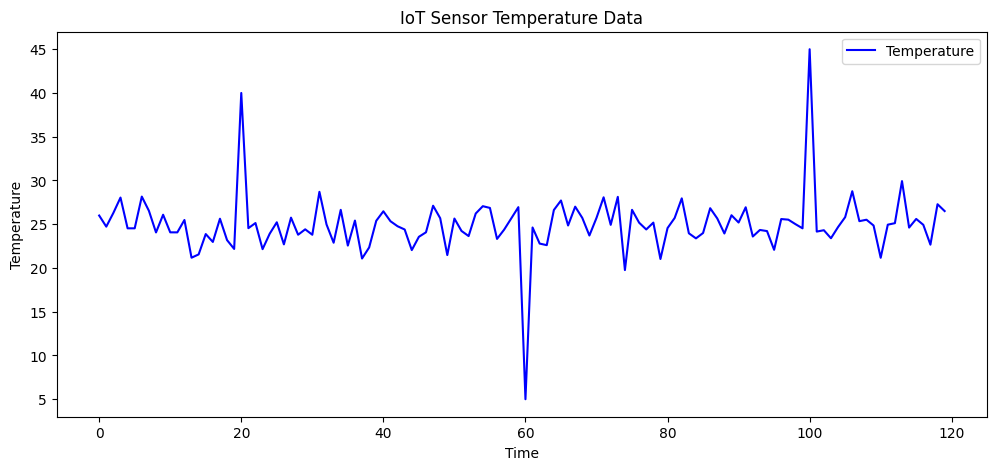

In [4]:
plt.figure(figsize=(12,5))
plt.plot(df['Time'], df['Temperature'], label='Temperature', color='blue')
plt.title("IoT Sensor Temperature Data")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.show()

## Anomaly Detection using Z-Score

Z-score helps identify how far a data point deviates from the mean.

In [5]:
# Calculate mean and std deviation
mean = df['Temperature'].mean()
std = df['Temperature'].std()

# Calculate Z-score
df['Z_score'] = (df['Temperature'] - mean) / std

# Define threshold
threshold = 2

# Mark anomalies
df['Anomaly'] = df['Z_score'].apply(lambda x: 1 if abs(x) > threshold else 0)

df.head()

,Time,Temperature,Z_score,Anomaly
0,0,25.993428,0.295379,0
1,1,24.723471,-0.072522,0
2,2,26.295377,0.382852,0
3,3,28.046060,0.890017,0
4,4,24.531693,-0.128079,0


## Results and Visualization of Anomalies

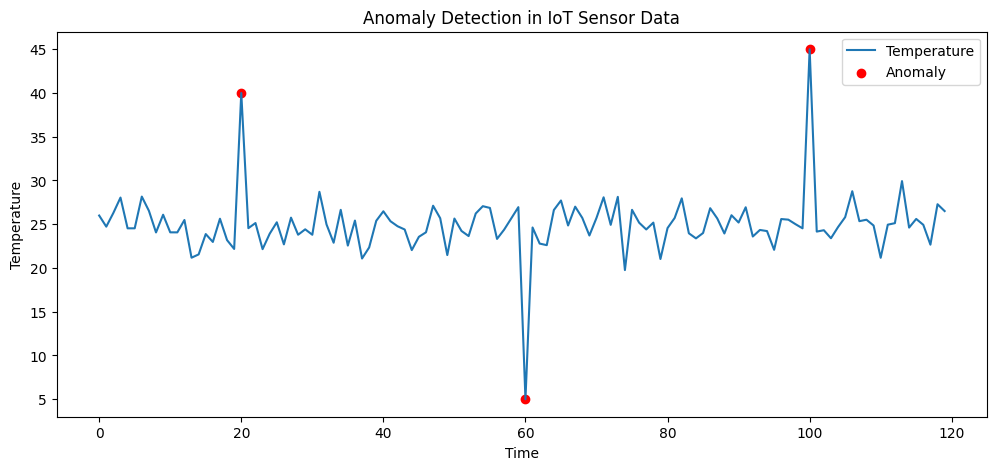

,Time,Temperature,Z_score,Anomaly
20,20,40.0,4.353019,1
60,60,5.0,-5.786322,1
100,100,45.0,5.801496,1


In [6]:
# Plot anomalies
plt.figure(figsize=(12,5))

plt.plot(df['Time'], df['Temperature'], label='Temperature')
plt.scatter(df[df['Anomaly']==1]['Time'],
            df[df['Anomaly']==1]['Temperature'],
            color='red', label='Anomaly')

plt.title("Anomaly Detection in IoT Sensor Data")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.show()

# Display anomalies
df[df['Anomaly'] == 1]

## Conclusion

The project successfully identifies abnormal sensor readings using a statistical approach. Such methods can be applied in real-world IoT systems for early fault detection and monitoring.